# Inspection of Pipeline Levels for a Subset of Data

In this notebook, we read in data from each level for a subset of the data from Bowman 2018. The idea is to be able to verify that filters etc. are working as expected, and ensure no bad data is getting through (on a small, 16-file subset of data).

In [2]:
%matplotlib inline
from edges_analysis import Level1
from edges_analysis import Level2
from edges_analysis import Level3
from edges_analysis import Level4
from edges_io import io
import matplotlib.pyplot as plt
import numpy as np
from edges_analysis.analysis import tools
from edges_cal import modelling as mdl

from edges_cal.xrfi import xrfi_model

## Level 1 (Calibration)

Here we simply choose a single file to inspect, to ensure the antenna S11 looks OK, and other simple checks. The calibration settings are here:

In [2]:
!cat settings/level1.yml

band: low
f_low: 50
f_high: 100
#calfile: /data4/nmahesh/edges/cal_file_Rcv01_2015_09.h5
#s11_path: /data5/edges/data/S11_antenna/low_band/20160830_a/s11
#switch_state_dir: #/data5/edges/data/CalibrationObservations/Receiver01/Receiver01_25C_2015_09_02_040_to_200MHz/S11/SwitchingState01
#balun_correction: true
#antenna_correction: false
#ground_correction: ':'
#beam_file: /home/nmahesh/edges-beams/low/beam_factors/feko_Haslam408_ref70.00_22f61e7c4b66d33e811dc6825b04001a.h5 #':feko_<edges_analysis.analysis.sky_models.Haslam408 object at 0x7f5e5c23aa30>_ref70.00_37f24754b5abc7224a1c24a3333c8ed4.h5'
#feko_gsm_ref100.00_a6823f3bf4d609908faaa5aeeb2b2b8a.h5'


To run this (subset) of data, run:

In [ ]:
!edges-analysis calibrate ....

In [3]:
l1 = Level1('/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_279_00_00_04.h5')

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:289: UserWarning: Extra key found in /data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_279_00_00_04.h5
  warnings.warn(f"Extra key found in {filename}")


### Antenna S11 Check

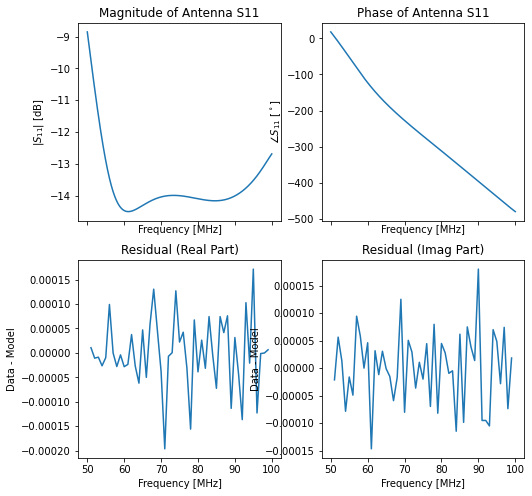

In [5]:
l1.plot_s11();

### Raw Data 

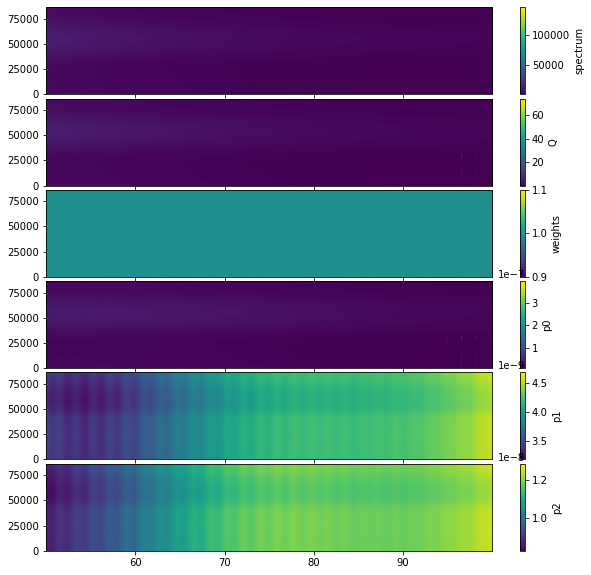

In [10]:
l1.plot_waterfalls();

It doesn't look like too much craziness in going on here.

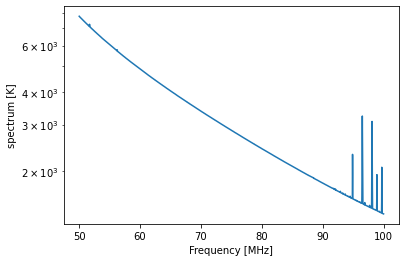

In [8]:
l1.plot_time_averaged_spectrum();

There is _definitely_ some RFI here (which is not surprising as we haven't done any xRFI).

### RFI Exploration

We can try to flag some RFI with different methods here:

In [32]:
flags = l1.rfi_filter(
    xrfi_pipe={
        'xrfi_model': {
            'n_signal': 6,
            'n_resid': 6,
            'threshold': 4,
            'max_iter': 20,
            'increase_order': False,
            'decrement_threshold': 0,
            'min_threshold': 3,
            'watershed': 4,
        },
        'xrfi_watershed': {
            'tol': 0.7
        }
    }
)

/data4/smurray/Projects/radio/EOR/Edges/edges-cal/src/edges_cal/xrfi.py:843: UserWarning: max iterations (20) reached, not all RFI might have been caught.
  f"max iterations ({max_iter}) reached, not all RFI might have been caught."
Process ForkPoolWorker-61:
Process ForkPoolWorker-53:
Process ForkPoolWorker-37:
Process ForkPoolWorker-57:
Process ForkPoolWorker-42:
Process ForkPoolWorker-47:
Process ForkPoolWorker-46:
Process ForkPoolWorker-40:
Process ForkPoolWorker-48:
Process ForkPoolWorker-39:
Process ForkPoolWorker-33:
Process ForkPoolWorker-44:
Process ForkPoolWorker-56:
Process ForkPoolWorker-58:
Process ForkPoolWorker-34:
Process ForkPoolWorker-64:
Process ForkPoolWorker-49:
Process ForkPoolWorker-52:
Process ForkPoolWorker-43:
Process ForkPoolWorker-38:
Process ForkPoolWorker-51:
Process ForkPoolWorker-55:
Process ForkPoolWorker-59:
Process ForkPoolWorker-35:
Process ForkPoolWorker-41:
Process ForkPoolWorker-45:
Process ForkPoolWorker-62:
Process ForkPoolWorker-36:
Process For

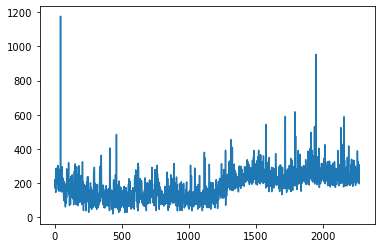

In [13]:
plt.plot(np.sum(flags, axis=1))

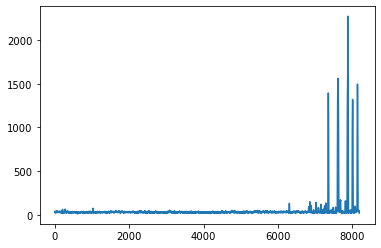

In [14]:
plt.plot(np.sum(flags, axis=0))

In [19]:
mean_spec, weights = tools.weighted_mean(l1.spectrum, weights=(~flags).astype(int), axis=0)

In [28]:
fit = mdl.ModelFit('polynomial', xdata=l1.freq.freq[weights>0], ydata=mean_spec[weights>0], weights=weights[weights>0], log_x=True, n_terms=7)

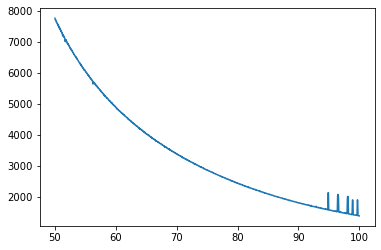

In [17]:
plt.plot(l1.freq.freq, tools.weighted_mean(l1.spectrum, weights=(~flags).astype(int), axis=0)[0])

In [27]:
np.any(np.isnan(mean_spec[weights>0]))

False

In [38]:
plt.plot(fit.xdata, fit.residual)

## Level 2

In [2]:
l2 = Level2('/home/smurray/edges/Steven/edges-cache/level-cache/level2/c8eb85794e645778e82d0fc9e0467a41/012449400d01e3c63a64ccc6f9e6a630.h5')

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:289: UserWarning: Extra key found in /home/smurray/edges/Steven/edges-cache/level-cache/level2/c8eb85794e645778e82d0fc9e0467a41/012449400d01e3c63a64ccc6f9e6a630.h5
  warnings.warn(f"Extra key found in {filename}")


<AxesSubplot:>

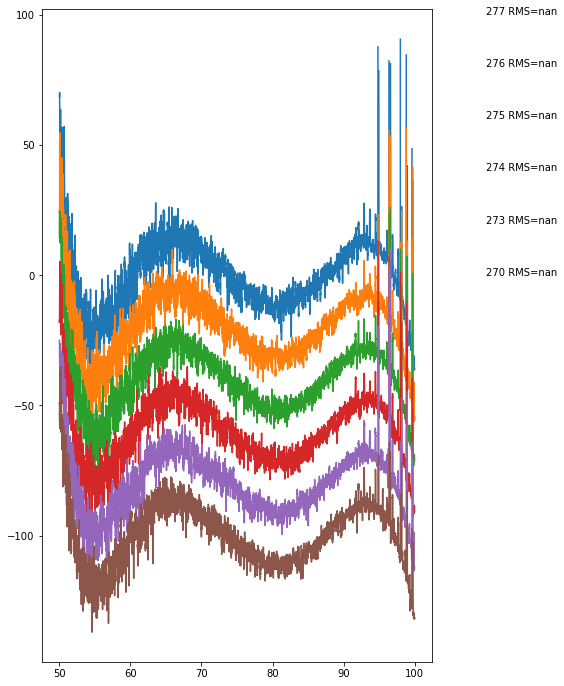

In [4]:
l2.plot_daily_residuals(separation=20)

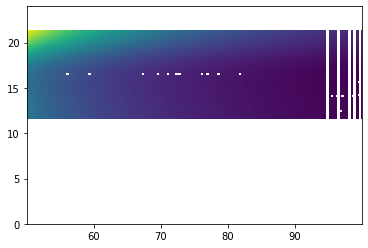

In [6]:
l2.plot_waterfall(day=277)

## Level 3

In [3]:
l3 = Level3('/home/smurray/edges/Steven/edges-cache/level-cache/level3/d8ad2f48683103df73bbe0ff42293ffd/012449400d01e3c63a64ccc6f9e6a630.h5')

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:289: UserWarning: Extra key found in /home/smurray/edges/Steven/edges-cache/level-cache/level3/d8ad2f48683103df73bbe0ff42293ffd/012449400d01e3c63a64ccc6f9e6a630.h5
  warnings.warn(f"Extra key found in {filename}")


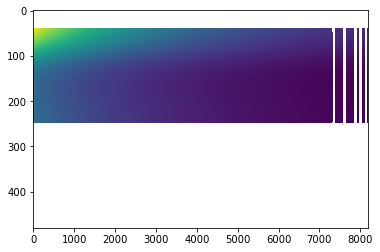

In [7]:
plt.imshow(l3.spectrum, aspect='auto')

In [16]:
xrfi_model?

In [18]:
flags = np.zeros(l3.spectrum.shape, dtype=bool)

for i, spec in enumerate(l3.spectrum):
    _flg, info = xrfi_model(spec, flags=l3.weights[i]==0, n_signal=7, n_resid=5, threshold=3.5, increase_order=False, watershed=4)
    flags[i] = _flg

/data4/smurray/Projects/radio/EOR/Edges/edges-cal/src/edges_cal/xrfi.py:808: RuntimeWarning: invalid value encountered in greater
  new_flags = orig_flags | (np.abs(res) > threshold * model_std)
/data4/smurray/Projects/radio/EOR/Edges/edges-cal/src/edges_cal/xrfi.py:823: RuntimeWarning: invalid value encountered in greater
  np.abs(res[rng]) > watershed[wrng] * threshold * model_std[rng]


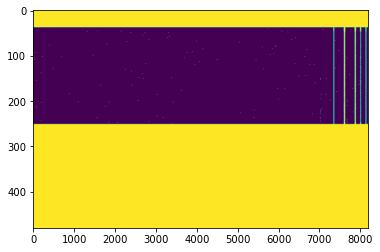

In [20]:
plt.imshow(flags, aspect='auto')

In [21]:
mean_spec, weights = tools.weighted_mean(l3.spectrum, axis=0, weights=np.where(flags, 0, l3.weights))

In [25]:
flags1d, info = xrfi_model(mean_spec, flags=weights==0, increase_order=False, threshold=3.5, n_resid=5, n_signal=7)

/data4/smurray/Projects/radio/EOR/Edges/edges-cal/src/edges_cal/xrfi.py:730: RuntimeWarning: invalid value encountered in less_equal
  orig_flags |= (spectrum <= 0) | np.isnan(spectrum) | np.isinf(spectrum)
/data4/smurray/Projects/radio/EOR/Edges/edges-cal/src/edges_cal/xrfi.py:808: RuntimeWarning: invalid value encountered in greater
  new_flags = orig_flags | (np.abs(res) > threshold * model_std)


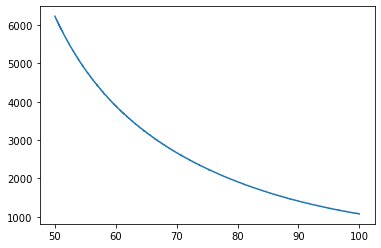

In [26]:
plt.plot(l3.freq.freq[~flags1d], mean_spec[~flags1d])

In [27]:
fit = mdl.ModelFit('polynomial', log_x=True, xdata=l3.freq.freq, weights=np.where(flags1d, 0, weights), ydata=mean_spec, n_terms=5)

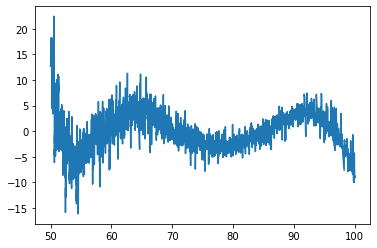

In [29]:
plt.plot(fit.xdata[~flags1d], fit.residual[~flags1d])

## Level 4

In [34]:
l4 = Level4('/home/smurray/edges/Steven/edges-cache/level-cache/level4/fc8a4a2c1382e2e0b034e25a43cff152/012449400d01e3c63a64ccc6f9e6a630.h5')

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:289: UserWarning: Extra key found in /home/smurray/edges/Steven/edges-cache/level-cache/level4/fc8a4a2c1382e2e0b034e25a43cff152/012449400d01e3c63a64ccc6f9e6a630.h5
  warnings.warn(f"Extra key found in {filename}")


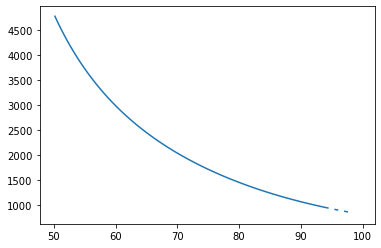

In [35]:
plt.plot(l4.freq.freq, l4.spectrum)

In [39]:
fit = mdl.ModelFit('polynomial', log_x=True, xdata=l4.freq.freq, weights=l4.weights, ydata=l4.spectrum, n_terms=8)

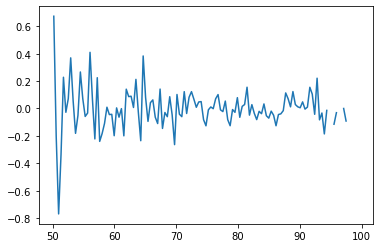

In [40]:
plt.plot(fit.xdata, fit.residual)

This looks like a fairly reasonable residual!